In [93]:
import digiflowio as dfi, matplotlib.pyplot as plt, numpy as np
import os
import importlib
from skimage.filters import threshold_otsu
from matplotlib import cm
# import scipy.signal
import pandas as pd
from scipy.optimize import curve_fit, brentq
import vortex_core
importlib.reload(vortex_core)
from vortex_core import find_vortex_cores_iterative


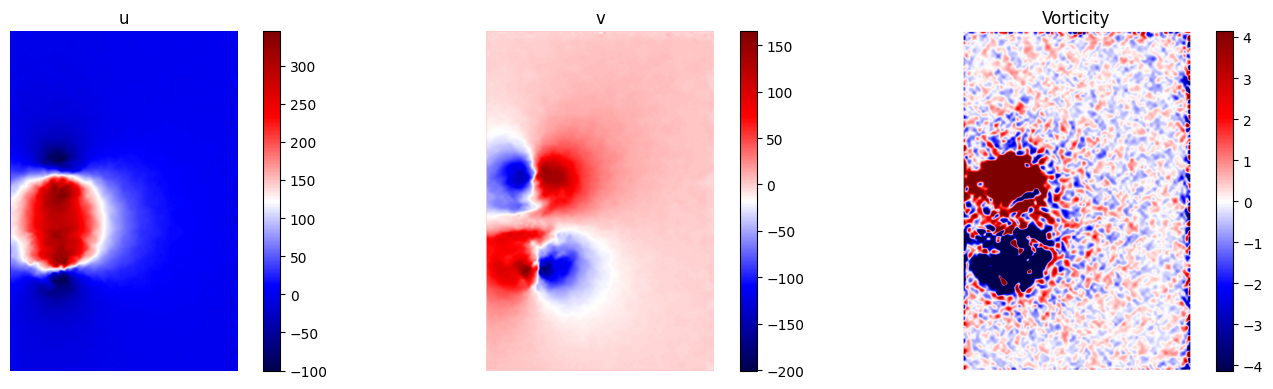

In [ ]:
# file of a specific frame
filepath = '/mnt/d/Users/zl483/highspeedcamera/bonus_test_11/Camera_1/vorticity_bonus_11_world_0136.dfi'
img = dfi.read(filepath, orientation="none")   # clockwise view
u, v, omega = img.data                               # unpack planes

# 1-a  show all three planes side-by-side
img.display()                                    # colour-bars included




In [128]:
# pixel to world coordinates mapping
coord_name = 'april_bonus'
quadratic_variables = ['1', 'x', 'x^2', 'y', 'y^2', 'xy', 'x^2*y', 'x*y^2']

# read the mapping coefficients from the .csv
# first row maps to world x, second row maps to world y
coord_file = f'/mnt/d/Users/zl483/highspeedcamera/{coord_name}_mapping.csv'
mappingX = np.loadtxt(coord_file, delimiter=',', skiprows=0, max_rows=1)
mappingY = np.loadtxt(coord_file, delimiter=',', skiprows=1, max_rows=1)

xPixel = np.arange(u.shape[1])
yPixel = np.arange(u.shape[0])

XPixel, YPixel = np.meshgrid(xPixel, yPixel)

XWorld = np.ones_like(XPixel) * mappingX[0] + \
            mappingX[1] * XPixel + \
            mappingX[2] * XPixel**2 + \
            mappingX[3] * YPixel + \
            mappingX[4] * YPixel**2 + \
            mappingX[5] * XPixel * YPixel + \
            mappingX[6] * XPixel**2 * YPixel + \
            mappingX[7] * XPixel * YPixel**2
YWorld = np.ones_like(YPixel) * mappingY[0] + \
            mappingY[1] * XPixel + \
            mappingY[2] * XPixel**2 + \
            mappingY[3] * YPixel + \
            mappingY[4] * YPixel**2 + \
            mappingY[5] * XPixel * YPixel + \
            mappingY[6] * XPixel**2 * YPixel + \
            mappingY[7] * XPixel * YPixel**2

dx = XWorld[0, 1] - XWorld[0, 0]  # assuming uniform grid spacing
dy = YWorld[1, 0] - YWorld[0, 0]


Text(0.5, 1.0, 'Vorticity with Velocity Vectors')

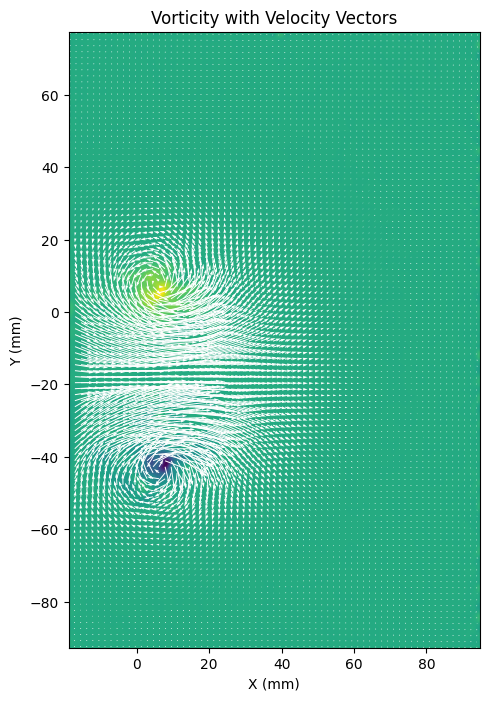

In [129]:
step = 10

# plot a vector field of (u, v) overlaid on the vorticity field
plt.figure(figsize=(10, 8))
plt.imshow(
    omega,
    cmap='viridis',
    origin='lower',
    extent=[XWorld.min(), XWorld.max(), YWorld.min(), YWorld.max()],
    aspect='equal'
)
# plt.colorbar(label='Vorticity')
plt.quiver(XWorld[::step, ::step], YWorld[::step, ::step], u[::step, ::step], v[::step, ::step], color='white', scale=3000)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Vorticity with Velocity Vectors')

### Identify core centres
(for simplicity, find core from max and min vorticity first)

[Pos] start (6.62, 5.62)
[Pos] iter 0: shift = 0.8294 mm  →  (5.91, 5.19)
[Pos] iter 1: shift = 0.2957 mm  →  (5.65, 5.05)
[Pos] iter 2: shift = 0.1115 mm  →  (5.55, 5.00)
[Pos] iter 3: shift = 0.0420 mm  →  (5.51, 4.99)
[Pos] converged after 4 iterations
[Neg] start (7.98, -41.61)
[Neg] iter 0: shift = 0.7712 mm  →  (7.22, -41.48)
[Neg] iter 1: shift = 0.3554 mm  →  (6.88, -41.40)
[Neg] iter 2: shift = 0.1896 mm  →  (6.69, -41.36)
[Neg] iter 3: shift = 0.1061 mm  →  (6.58, -41.35)
[Neg] iter 4: shift = 0.0583 mm  →  (6.53, -41.34)
[Neg] converged after 5 iterations

Positive core : (5.5, 5.0) mm  Γ = 11507.5 mm²/s
Negative core : (6.5, -41.3) mm  Γ = -9178.4 mm²/s
Centreline y  : -18.2 mm  (row index 448)
Ring radius   : 23.2 mm

Detected 2 cores


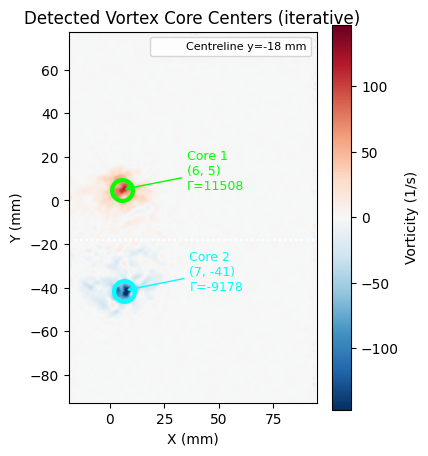

In [130]:
fit_radius = 10.0   # mm — fitting window for iterative core finder

cores_auto, centerline_idx, gammas = find_vortex_cores_iterative(
    XWorld, YWorld, omega,
    fit_radius=fit_radius,
    verbose=True,
)

(xc_pos, yc_pos, _), (xc_neg, yc_neg, _) = cores_auto
centerline_y = 0.5 * (yc_pos + yc_neg)
ring_radius = 0.5 * np.abs(yc_pos - yc_neg)
print(f"\nPositive core : ({xc_pos:.1f}, {yc_pos:.1f}) mm  Γ = {gammas[0]:.1f} mm²/s")
print(f"Negative core : ({xc_neg:.1f}, {yc_neg:.1f}) mm  Γ = {gammas[1]:.1f} mm²/s")
print(f"Centreline y  : {centerline_y:.1f} mm  (row index {centerline_idx})")
print(f"Ring radius   : {ring_radius:.1f} mm")
print(f"\nDetected {len(cores_auto)} cores")

fig, ax = plt.subplots(figsize=(4, 5))
vmax = np.abs(omega).max() * 0.8
im = ax.pcolormesh(XWorld, YWorld, omega, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto')
plt.colorbar(im, ax=ax, label='Vorticity (1/s)')

for i, (xc, yc, sign) in enumerate(cores_auto):
    color = 'lime' if sign > 0 else 'cyan'
    ax.plot(xc, yc, 'o', markersize=15, markerfacecolor='none',
            markeredgecolor=color, markeredgewidth=3)
    ax.annotate(f'Core {i+1}\n({xc:.0f}, {yc:.0f})\nΓ={gammas[i]:.0f}',
                xy=(xc, yc), xytext=(xc+30, yc),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color))

ax.axhline(centerline_y, color='white', linestyle=':', linewidth=1.5, label=f'Centreline y={centerline_y:.0f} mm')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_title('Detected Vortex Core Centers (iterative)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.show()


In [ ]:
# Select which core to analyze (0 = first core, 1 = second core)
CORE_INDEX = 0

core_x, core_y, core_sign = cores_auto[CORE_INDEX]
gamma_fitted = gammas[CORE_INDEX]


print(f"Analyzing Core {CORE_INDEX + 1}:")
print(f"  Position: ({core_x:.1f}, {core_y:.1f}) mm")
print(f"  Vorticity sign: {core_sign:+d}")
print(f"  Circulation Γ (ellipse): {gamma_fitted:.1f} mm²/s")

# prepare field for the relevant core
if core_sign > 0:
    print("  Analyzing positive vorticity core (e.g., upper core)")
    omega_core = omega[int(centerline_y):, :]
else:
    print("  Analyzing negative vorticity core (e.g., lower core)")
    omega_core = omega[:int(centerline_y), :]


Analyzing Core 1:
  Position: (5.5, 5.0) mm
  Vorticity sign: +1
  Circulation Γ (ellipse): 11507.5 mm²/s
  Analyzing positive vorticity core (e.g., upper core)


---
## Step 5: Transform to Polar Coordinates Centered on Core

For each grid point, compute:
- $\rho = \sqrt{(x - x_c)^2 + (y - y_c)^2}$ — radial distance from core
- $\phi = \arctan2(y - y_c, x - x_c)$ — azimuthal angle

omega_half shape: (576, 685), mask shape: (576, 685)
Radial distance range: 0.1 to 7.0
Azimuthal angle range: -179.9° to 178.7°


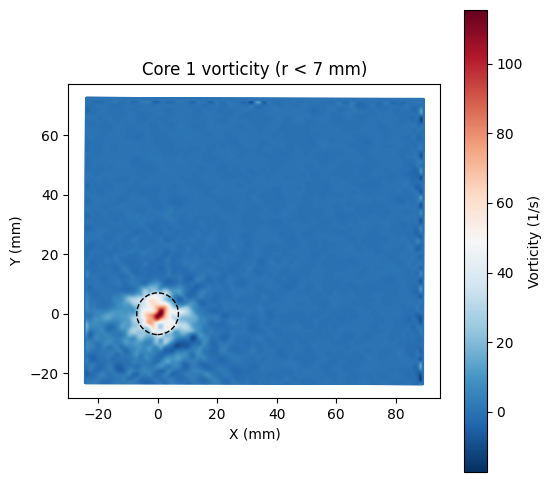

In [132]:
# Displacement from core center
dX = XWorld - core_x # in mm
dY = YWorld - core_y # in mm

# keep only the relevant half-plane for analysis
if core_sign > 0:
    dX = dX[centerline_idx:, :]
    dY = dY[centerline_idx:, :]
    omega_half = omega[centerline_idx:, :]
else:
    dX = dX[:centerline_idx, :]
    dY = dY[:centerline_idx, :]
    omega_half = omega[:centerline_idx, :]

# Polar coordinates
rho = np.sqrt(dX**2 + dY**2)       # radial distance, in mm
phi = np.arctan2(dY, dX)           # azimuthal angle (radians)

####################                 only if fitting an elliptical model   ############################
# apply a mask to keep only points within a certain radius
radius_threshold = 7
mask = rho <= radius_threshold

# extract the corresponding values for the masked points
rho_masked = rho[mask]
phi_masked = phi[mask]
omega_masked = omega_half[mask]

print(f"omega_half shape: {omega_half.shape}, mask shape: {mask.shape}")
print(f"Radial distance range: {rho_masked.min():.1f} to {rho_masked.max():.1f}")
print(f"Azimuthal angle range: {np.degrees(phi_masked.min()):.1f}° to {np.degrees(phi_masked.max()):.1f}°")

plt.figure(figsize=(6, 6))
# scatter the omega_half and draw a circle at the radius threshold for visualization
plt.scatter(dX, dY, c=omega_half, cmap='RdBu_r', s=1, alpha=1)
circle = plt.Circle((0, 0), radius_threshold, color='black', fill=False, linestyle='--')
plt.gca().add_artist(circle)
# plt.scatter(dX[mask], dY[mask], c=omega_masked, cmap='RdBu_r', s=1)
plt.colorbar(label='Vorticity (1/s)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.gca().set_aspect('equal')
plt.title(f'Core {CORE_INDEX + 1} vorticity (r < {radius_threshold} mm)')
plt.show()

---
## Step 6: Compute Tangential and Radial Velocity Components

Transform from Cartesian $(u, v)$ to polar $(u_\rho, u_\theta)$:

$$u_\rho = u \cos\phi + v \sin\phi \quad \text{(radial)}$$
$$u_\theta = -u \sin\phi + v \cos\phi \quad \text{(tangential)}$$

Convention: positive $u_\theta$ is counter-clockwise.

Non-dimensionalized mean velocity U_mean_nd: 2.93
Effective core size a_eff: 7.74 mm


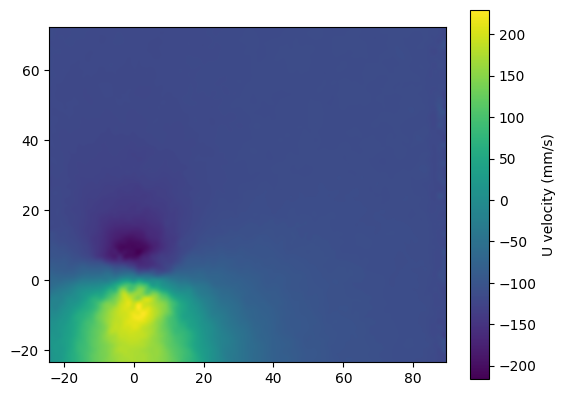

In [133]:
#### FIRST define the field to be used
rho_to_use = rho.copy()
phi_to_use = phi.copy()
omega_to_use = omega_half.copy()
U_to_use = u[int(centerline_idx):, :].copy()
V_to_use = v[int(centerline_idx):, :].copy()
X_to_use =dX.copy()
Y_to_use = dY.copy()   
    
# Subtract mean flow first (estimate from far-field)
# This removes the ring's translational velocity
U_mean = 115.662 # mm/s
V_mean = 0.0    # mm/s

U_mean_nd = 4 * np.pi * U_mean * ring_radius / np.abs(gamma_measured)
print(f"Non-dimensionalized mean velocity U_mean_nd: {U_mean_nd:.2f}")

a_eff = 8 * ring_radius * np.exp(-U_mean_nd-1/4)
print(f"Effective core size a_eff: {a_eff:.2f} mm")

U_rel = U_to_use - U_mean
V_rel = V_to_use - V_mean

# sanity check of U_to_use, use quiver plot to check the raw velocity field
# AXES should display the correct physical coordinates (XWorld, YWorld) and not pixel coordinates (XPixel, YPixel)

plt.imshow(U_rel, cmap='viridis', origin='lower', extent=[X_to_use.min(), X_to_use.max(), Y_to_use.min(), Y_to_use.max()], aspect='equal')
plt.colorbar(label='U velocity (mm/s)')


## Step 8.2 What about elliptic equation to fit voriticity field?

In [134]:
# =============================================================================
# Quadratic vorticity fit → velocity profile
# =============================================================================
# ============================================================================
# Elliptical (2D quadratic) vorticity fit
# ============================================================================
# Fits the vorticity field near the core to a 2D quadratic:
#   ω(x', y') = a0 + a1·x' + a2·x'² + a3·x'·y' + a4·y' + a5·y'²
# 
# where (x', y') are displacements from the current core centre estimate.
# The Hessian gives principal curvatures, from which core radii are extracted
# assuming a parabolic vorticity profile: ω(r) = ω_c·(1 - r²/a²).

def quadratic_vorticity_model(xy, a0, a1, a2, a3, a4, a5):
    """
    2D quadratic model for the vorticity field.
    
    Parameters
    ----------
    xy : tuple (x_prime, y_prime)
        Displacement arrays from the reference core centre.
    a0–a5 : float
        Quadratic coefficients.
    """
    x_prime, y_prime = xy
    return (a0 
            + a1 * x_prime 
            + a2 * x_prime**2 
            + a3 * x_prime * y_prime 
            + a4 * y_prime 
            + a5 * y_prime**2)


def analyze_elliptical_core(coeffs):
    """
    Extract core characteristics from quadratic fit coefficients.
    
    For a parabolic profile ω(r) = ω_c·(1 - r²/a²), the 2nd derivative along
    a principal direction is -2·ω_c/a², so:  a = sqrt(-2·ω_c / λ).
    This requires ω_c and λ to have opposite signs (extremum condition).
    
    Returns
    -------
    dict with:
        omega_c   : peak vorticity at the quadratic's extremum (1/s)
        x0, y0    : location of extremum relative to core centre (mm)
        a_xi      : semi-axis along principal direction 1 (mm)
        a_eta     : semi-axis along principal direction 2 (mm)
        a_eq      : equivalent (geometric-mean) radius = sqrt(a_ξ·a_η)
        tilt      : orientation of the major axis w.r.t. x-axis (degrees)
        H         : Hessian matrix
        lambdas   : eigenvalues of Hessian
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    
    # Hessian of ω: H_xx = 2a2, H_yy = 2a5, H_xy = a3
    H = np.array([[2*a2, a3],
                  [a3,   2*a5]])
    
    # Extremum location: ∇ω = 0  →  H·[x0,y0] = -[a1, a4]
    grad = np.array([a1, a4])
    try:
        x0, y0 = np.linalg.solve(H, -grad)
    except np.linalg.LinAlgError:
        x0, y0 = 0.0, 0.0
    
    # Peak vorticity at the extremum
    omega_c = quadratic_vorticity_model((x0, y0), *coeffs)
    
    # Principal curvatures
    eigenvalues, eigenvectors = np.linalg.eig(H)
    lambda1, lambda2 = eigenvalues
    
    # Principal semi-axes (valid only when curvature opposes ω_c sign)
    a_xi  = np.sqrt(-2*omega_c/lambda1) if (omega_c*lambda1) < 0 else np.nan
    a_eta = np.sqrt(-2*omega_c/lambda2) if (omega_c*lambda2) < 0 else np.nan
    
    if np.isfinite(a_xi) and np.isfinite(a_eta):
        a_eq = np.sqrt(a_xi * a_eta)
    else:
        a_eq = np.nan
    
    # Tilt: direction of the MAJOR axis (smaller |curvature| → larger radius)
    idx_major = np.argmin(np.abs(eigenvalues))
    major_vec = eigenvectors[:, idx_major]
    tilt = np.degrees(np.arctan2(major_vec[1], major_vec[0]))
    
    return {
        'omega_c': omega_c,
        'x0': x0, 'y0': y0,
        'a_xi': a_xi, 'a_eta': a_eta, 'a_eq': a_eq,
        'tilt': tilt,
        'H': H,
        'lambda1': lambda1, 'lambda2': lambda2,
    }


def parabolic_vorticity_velocity(r, omega_c, a):
    """
    Tangential velocity derived from a parabolic vorticity distribution:
        ω(r) = ω_c · (1 - r²/a²)    for r ≤ a
        ω(r) = 0                    for r > a
    
    Integrating ω = (1/r)·d(r·u_θ)/dr gives:
        u_θ(r) = (ω_c · r / 2) · (1 - r²/(2a²))   for r ≤ a
        u_θ(r) = ω_c · a² / (4r)                   for r > a
    
    with circulation Γ = π·ω_c·a² / 2.
    """
    r = np.asarray(r, dtype=float)
    u_theta = np.zeros_like(r)
    
    inner = r <= a
    outer = r > a
    
    u_theta[inner] = (omega_c * r[inner] / 2) * (1 - r[inner]**2 / (2*a**2))
    u_theta[outer] = omega_c * a**2 / (4 * r[outer])

    # find the radius of peak velocity (inner core radius)
    ai = r[inner][np.argmax(u_theta[inner])]
    
    return np.abs(u_theta), ai



In [135]:
# ============================================================================
# Fit quadratic vorticity to the masked data from Cell 8
# ============================================================================
# Uses: rho_masked, phi_masked, omega_masked, radius_threshold

# Reconstruct (x', y') displacements from the polar coordinates
dX_masked = X_to_use[mask]  # or simply dX[mask]
dY_masked = Y_to_use[mask]  # or simply dY[mask]

print(f"Fitting 2D quadratic to {len(omega_masked)} vorticity points "
      f"within ρ ≤ {radius_threshold} mm")

# Initial guesses: centred parabolic bump with curvature ~ -ω_c / r_thresh²
omega_c_guess = core_sign * np.abs(omega_masked).max()
curv_guess = -omega_c_guess / radius_threshold**2
p0 = [omega_c_guess, 0.0, curv_guess, 0.0, 0.0, curv_guess]

try:
    popt_vort, pcov_vort = curve_fit(
        quadratic_vorticity_model,
        (dX_masked, dY_masked),
        omega_masked,
        p0=p0,
        maxfev=10000
    )
    
    # Analyse the fit
    ellipse = analyze_elliptical_core(popt_vort)
    
    omega_c = ellipse['omega_c']
    a_xi = ellipse['a_xi']
    a_eta = ellipse['a_eta']
    a_eq = ellipse['a_eq']
    tilt_angle = ellipse['tilt']
    
    print("\nQuadratic vorticity fit results:")
    print(f"  Peak vorticity   ω_c = {omega_c:.2f} 1/s")
    print(f"  Extremum offset       = ({ellipse['x0']:.2f}, {ellipse['y0']:.2f}) mm")
    print(f"  Principal semi-axes:  a_ξ = {a_xi:.2f} mm,  a_η = {a_eta:.2f} mm")
    print(f"  Equivalent radius    a_eq = {a_eq:.2f} mm")
    print(f"  Ellipse tilt              = {tilt_angle:.1f}°")
    
    # Validity check: radii should be within the fit window
    if np.isfinite(a_eq):
        max_radius = max(a_xi, a_eta) if np.isfinite(a_xi*a_eta) else a_eq
        if max_radius > 0.8 * radius_threshold:
            print(f"\n  ⚠  Warning: largest radius ({max_radius:.1f} mm) is close to "
                  f"fit window ({radius_threshold} mm). Consider enlarging the "
                  f"window or validate with numerical integration of u_θ.")
    
    # Implied circulation from the parabolic vorticity model
    if np.isfinite(a_eq):
        gamma_parab = np.pi * np.abs(omega_c) * a_eq**2 / 2
        print(f"  Implied circulation  Γ = {gamma_parab:.0f} mm²/s")
    else:
        gamma_parab = np.nan
    
    quadratic_fit_success = True
    
except Exception as e:
    print(f"Quadratic vorticity fit failed: {e}")
    omega_c = np.nan
    a_xi = a_eta = a_eq = np.nan
    tilt_angle = np.nan
    gamma_parab = np.nan
    quadratic_fit_success = False



Fitting 2D quadratic to 5608 vorticity points within ρ ≤ 7 mm

Quadratic vorticity fit results:
  Peak vorticity   ω_c = 78.17 1/s
  Extremum offset       = (0.06, 0.16) mm
  Principal semi-axes:  a_ξ = 7.99 mm,  a_η = 8.77 mm
  Equivalent radius    a_eq = 8.37 mm
  Ellipse tilt              = -52.9°

  ⚠  Warning: largest radius (8.8 mm) is close to fit window (7 mm). Consider enlarging the window or validate with numerical integration of u_θ.
  Implied circulation  Γ = 8607 mm²/s


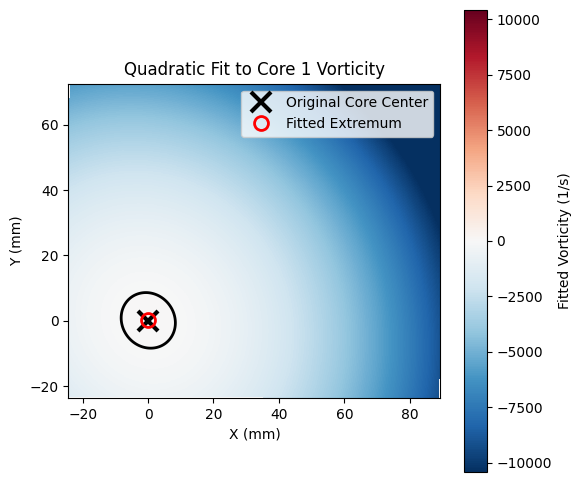

In [136]:
# reconstruct the fitted vorticity field for visualization
if quadratic_fit_success:
    omega_fit = quadratic_vorticity_model((dX, dY), *popt_vort)
    
    plt.figure(figsize=(6, 6))
    vmax_fit = np.percentile(np.abs(omega_fit), 95)
    plt.pcolormesh(dX, dY, omega_fit, cmap='RdBu_r', vmin=-vmax_fit, vmax=vmax_fit, shading='auto')
    plt.colorbar(label='Fitted Vorticity (1/s)')
    # plot to 0-level contour to visualize the core boundary
    plt.contour(dX, dY, omega_fit, levels=[0], colors='black', linewidths=2)
    # mark the original core center and the fitted extremum
    plt.plot(0, 0, 'kx', markersize=15, markeredgewidth=3, label='Original Core Center')
    plt.plot(ellipse['x0'], ellipse['y0'], 'ro', markersize=10, markerfacecolor='none', markeredgewidth=2, label='Fitted Extremum')
    plt.legend()
    plt.xlabel('X (mm)')
    plt.ylabel('Y (mm)')
    plt.title(f'Quadratic Fit to Core {CORE_INDEX + 1} Vorticity')
    plt.gca().set_aspect('equal')
    plt.show()

What is a good measure for ellipticity?

### Transform the cartesian coordinate into polar centered around fitted (x0, y0)

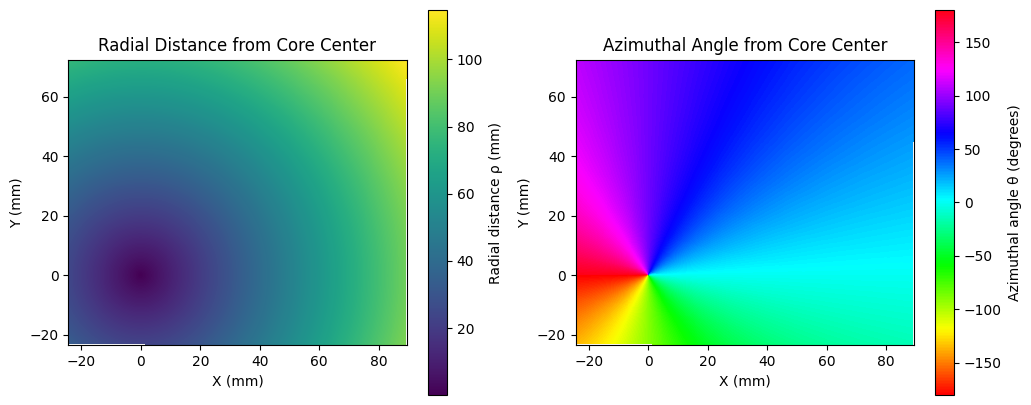

In [137]:

# Polar coordinates are already centred on the iterative core (computed in Step 5)
# No second shift needed: find_vortex_cores_iterative already gives the precise centre
rho_polar   = rho_to_use
theta_polar = phi_to_use

# color plot for visualizing the polar coordinates
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im = ax[0].pcolormesh(X_to_use, Y_to_use, rho_polar, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax[0], label='Radial distance ρ (mm)')
ax[0].set_title('Radial Distance from Core Center')
ax[0].set_xlabel('X (mm)')
ax[0].set_ylabel('Y (mm)')
ax[0].set_aspect('equal')
im = ax[1].pcolormesh(X_to_use, Y_to_use, np.degrees(theta_polar), cmap='hsv', shading='auto')
plt.colorbar(im, ax=ax[1], label='Azimuthal angle θ (degrees)')
ax[1].set_title('Azimuthal Angle from Core Center')
ax[1].set_xlabel('X (mm)')
ax[1].set_ylabel('Y (mm)')
ax[1].set_aspect('equal')


compute velocity in polar coordinate:
$$u_\rho = u_x \cos{\theta} + u_y \sin{\theta}$$
$$u_\theta = - u_x \sin{\theta} + u_y \cos{\theta}

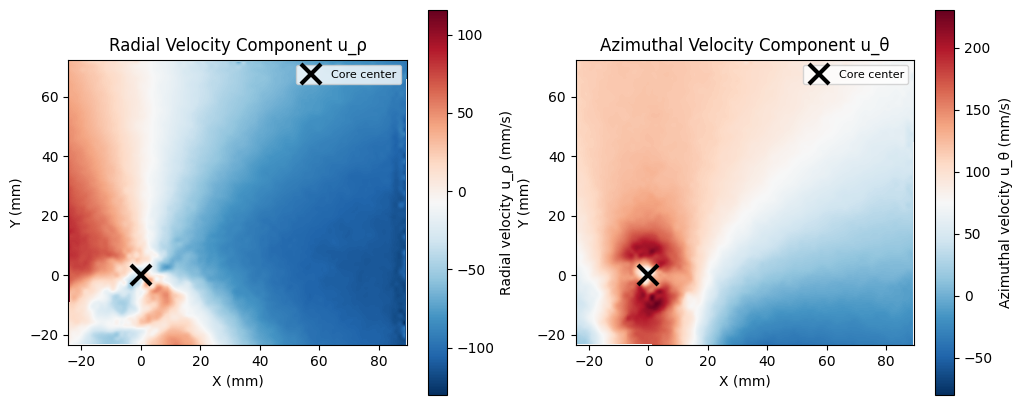

In [138]:
u_rho   =  U_rel * np.cos(theta_polar) + V_rel * np.sin(theta_polar)
u_theta = -U_rel * np.sin(theta_polar) + V_rel * np.cos(theta_polar)
u_theta_signed = core_sign * u_theta

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im = ax[0].pcolormesh(X_to_use, Y_to_use, u_rho, cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax[0], label='Radial velocity u_ρ (mm/s)')
ax[0].set_title('Radial Velocity Component u_ρ')
ax[0].set_xlabel('X (mm)')
ax[0].set_ylabel('Y (mm)')
ax[0].set_aspect('equal')
im = ax[1].pcolormesh(X_to_use, Y_to_use, u_theta, cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax[1], label='Azimuthal velocity u_θ (mm/s)')
ax[1].set_title('Azimuthal Velocity Component u_θ')
ax[1].set_xlabel('X (mm)')
ax[1].set_ylabel('Y (mm)')
ax[1].set_aspect('equal')
# mark the core centre (origin of the displaced frame) on both panels
for a in ax:
    a.plot(0, 0, 'kx', markersize=15, markeredgewidth=3, label='Core center')
    a.legend(fontsize=8)


In [106]:
# Parameters for binning
r_max = 25   # maximum radius to analyze (mm)
n_bins = 100   # number of radial bins

# Create radial bins
r_edges = np.linspace(0, r_max, n_bins + 1)
r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
dr = r_edges[1] - r_edges[0]

print(f"Radial bin width: {dr:.2f} mm")
print(f"Number of bins: {n_bins}")

Radial bin width: 0.25 mm
Number of bins: 100


Points per bin: min=7, max=1334, mean=706


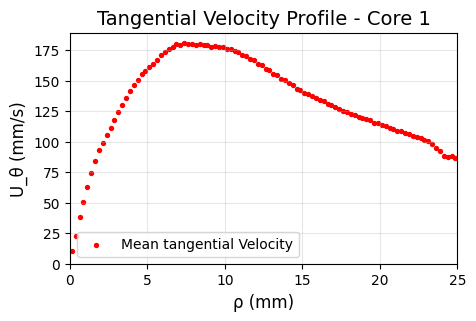

In [139]:
# Flatten arrays for easier binning
rho_flat = rho.flatten()
u_theta_flat = u_theta_signed.flatten()
u_rho_flat = u_rho.flatten()

# Initialize output arrays
U_theta_mean = np.zeros(n_bins)
U_theta_std = np.zeros(n_bins)
U_rho_mean = np.zeros(n_bins)
n_points = np.zeros(n_bins, dtype=int)

# Bin and average
for i in range(n_bins):
    # Find points in this radial bin
    mask = (rho_flat >= r_edges[i]) & (rho_flat < r_edges[i+1])
    n_points[i] = np.sum(mask)
    
    if n_points[i] > 0:
        U_theta_mean[i] = np.mean(u_theta_flat[mask])
        U_theta_std[i] = np.std(u_theta_flat[mask])
        U_rho_mean[i] = np.mean(u_rho_flat[mask])

print(f"Points per bin: min={n_points.min()}, max={n_points.max()}, mean={n_points.mean():.0f}")

# Quick look at the profile
plt.figure(figsize=(5, 3))

valid = n_points > 2  # only plot bins with enough data
# plt.errorbar(r_centers[valid], U_theta_mean[valid], yerr=U_theta_std[valid],
#              fmt='o-', markersize=5, capsize=3, label='Experimental')
plt.scatter(r_centers[valid], U_theta_mean[valid], color='red', s=8, label='Mean tangential Velocity')
plt.xlabel('ρ (mm)', fontsize=12)
plt.ylabel('U_θ (mm/s)', fontsize=12)
plt.title(f'Tangential Velocity Profile - Core {CORE_INDEX+1}', fontsize=14)
plt.xlim(0, r_max)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [140]:
def rankine_vortex(r, gamma, a):
    """Rankine vortex velocity profile."""
    u_theta = np.zeros_like(r)
    inner = r <= a
    outer = r > a
    
    u_theta[inner] = gamma * r[inner] / (2 * np.pi * a**2)
    u_theta[outer] = gamma / (2 * np.pi * r[outer])
    
    ai = a
    return u_theta, ai


def lamb_oseen(r, gamma, a):
    """Lamb-Oseen vortex velocity profile."""
    r_safe = np.maximum(r, 1e-10)  # avoid division by zero
    u_theta = gamma / (2 * np.pi * r_safe) * (1 - np.exp(-r**2 / a**2))
    
    # solve for root, derived analytical solution
    ai = 1.121 * a  # ai = a * sqrt(root), where root ≈ 1.25643 from the equation x^2 = 1 - exp(-x^2)
    return u_theta, ai  # return the effective core radius ai = a * sqrt(root)

# =============================================================================
# Add this to Step 8, after the Rankine and Lamb-Oseen definitions
# =============================================================================

from scipy.special import hyp1f1  # confluent hypergeometric function 1F1

from scipy.special import hyp1f1  # Kummer's M(a; b; z)
from scipy.integrate import quad
import numpy as np

# ============================================================================
# Saffman (1978) hypergeometric profile
# ============================================================================
# Reference: Saffman, J. Fluid Mech. 84 (1978), eq. (2.16)
#
#   Ω(s) = M(3/4; 2; -s²/ε²) / M(3/4; 2; -1/ε²)    for s ≤ 1
#
# where Ω(s) is the dimensionless angular velocity, s = r/a, and M is
# Kummer's confluent hypergeometric function. The viscous parameter ε is
# defined in eq. (3.5):  ε² = 4νt/a²  (viscous diffusion length / core radius).
#
# Tangential velocity: V(r) = r · Ω(s) · (V(a)/a), matched to potential flow
# outside the core where V(a) = Γ/(2πa).

from scipy.special import hyp1f1  # Kummer's M(a; b; z)

def saffman_profile(r, gamma, a, epsilon):
    """
    Saffman (1978) hypergeometric velocity profile.
    
    Parameters
    ----------
    r : array-like
        Radial distance from core centre (mm).
    gamma : float
        Circulation (mm²/s).
    a : float
        Core radius — boundary between inner Kummer profile and outer 
        potential flow (mm).
    epsilon : float
        Saffman's viscous parameter, ε² = 4νt/a².
        Small ε → concentrated core (approaches Kaden spiral s^(-3/2) as ε→0).
        Large ε → diffuse core (approaches solid-body rotation as ε→∞).
    
    Returns
    -------
    u_theta : ndarray
        Tangential velocity (mm/s).
    """
    r = np.asarray(r, dtype=float)
    u_theta = np.zeros_like(r)
    
    # Normalisation: M(3/4; 2; -1/ε²) at s = 1
    M_norm = hyp1f1(0.75, 2.0, -1.0 / epsilon**2)
    
    # Inside the core (s ≤ 1): Kummer-function profile
    inner = r <= a
    s_inner = r[inner] / a
    u_theta[inner] = (gamma / (2 * np.pi * a)) * s_inner * \
                     hyp1f1(0.75, 2.0, -s_inner**2 / epsilon**2) / M_norm
    
    # Outside the core (s > 1): potential flow
    outer = r > a
    u_theta[outer] = gamma / (2 * np.pi * r[outer])
    
    return u_theta


In [141]:
# Prepare data for fitting (exclude bins with few points)
valid = (n_points > 2) & (r_centers > 0) & (U_theta_mean > 0)
r_fit = r_centers[valid]
u_fit = U_theta_mean[valid]

# Initial guesses used the measured values 
# At large r: u_theta ≈ Γ/(2πr), so Γ ≈ 2πr·u_theta
gamma_guess = gamma_measured

# Peak velocity location gives estimate of core radius
i_peak = np.argmax(u_fit)
a_guess = r_fit[i_peak] if i_peak > 0 else r_fit[1]

print(f"Initial guesses: Γ = {gamma_guess:.0f} mm²/s, a = {a_guess:.1f} mm")

Initial guesses: Γ = 11508 mm²/s, a = 7.4 mm


In [142]:
# fit rankine vortex
popt_rankine, _ = curve_fit(lambda r, gamma, a: rankine_vortex(r, gamma, a)[0], r_fit, u_fit, p0=[gamma_guess, a_guess])
gamma_rankine, ai_rankine = popt_rankine

peakness_rankine = ai_rankine / a_eff
epsilon_tankine = 0.47 * peakness_rankine / (1.45 - 0.63 * peakness_rankine)  # empirical formula to estimate ε from peakness
print(f"Rankine fit: Γ = {gamma_rankine:.0f} mm²/s, a = {ai_rankine:.1f} mm, ε = {epsilon_tankine:.2f}, peakness = {peakness_rankine:.2f}")


Rankine fit: Γ = 12337 mm²/s, a = 8.3 mm, ε = 0.65, peakness = 1.07


In [143]:
# Fit Lamb-Oseen model
try:
    popt, pcov = curve_fit(lamb_oseen, r_fit, u_fit,
                           p0=[gamma_guess, a_guess],
                           bounds=([0, 0], [np.inf, np.inf]),
                           maxfev=5000)
    
    gamma_fit, a_fit = popt
    gamma_err, a_err = np.sqrt(np.diag(pcov))
    
    print("Lamb-Oseen fit results:")
    print(f"  Circulation Γ = {gamma_fit:.0f} ± {gamma_err:.0f} mm²/s")
    print(f"  Core radius a = {a_fit:.1f} ± {a_err:.1f} mm")
    
    fit_success = True
    
except Exception as e:
    print(f"Fitting failed: {e}")
    gamma_fit, a_fit = gamma_guess, a_guess
    fit_success = False


Fitting failed: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.


In [144]:
# Find inner core radius (location of peak tangential velocity)
i_peak = np.argmax(U_theta_mean[valid])
a_inner = r_centers[valid][i_peak]
U_theta_peak = U_theta_mean[valid][i_peak]

peakness_actual = a_inner / a_eff
epsilon_actual = 0.47 * peakness_actual / (1.45 - 0.63 * peakness_actual)  # empirical formula to estimate ε from peakness
print(f"\nActual Inner core radius (peak u_θ location): a_i = {a_inner:.1f} mm")
print(f"Peak tangential velocity: U_θ_max = {U_theta_peak:.1f} mm/s")
print(f"Actual peakness: {peakness_actual:.2f}")
print(f"Actual ε: {epsilon_actual:.2f}")


Actual Inner core radius (peak u_θ location): a_i = 7.4 mm
Peak tangential velocity: U_θ_max = 180.8 mm/s
Actual peakness: 0.95
Actual ε: 0.53


In [145]:
# Fit Saffman hypergeometric model
# ============================================================================
# Fit Saffman hypergeometric model
# ============================================================================
# Uses the already-fitted Lamb-Oseen parameters (gamma_fit, a_fit) as initial
# guesses. The viscous parameter ε starts at 0.3 (typical for ~moderate cores).

try:
    popt_saf, pcov_saf = curve_fit(
        saffman_profile, r_fit, u_fit,
        p0=[gamma_fit, a_fit, 0.3],
        bounds=([0, 0, 0.01], [np.inf, np.inf, 2.0]),
        maxfev=10000
    )
    
    gamma_saf, a_saf, epsilon_saf = popt_saf
    gamma_saf_err, a_saf_err, epsilon_saf_err = np.sqrt(np.diag(pcov_saf))
    
    print("Saffman hypergeometric fit results:")
    print(f"  Circulation     Γ = {gamma_saf:.0f} ± {gamma_saf_err:.0f} mm²/s")
    print(f"  Core radius     a = {a_saf:.2f} ± {a_saf_err:.2f} mm")
    print(f"  Viscous param   ε = {epsilon_saf:.3f} ± {epsilon_saf_err:.3f}")
    
    # Derived quantities (Saffman 1978, eq. 2.17 — valid for ε < 0.5)
    # s1 = a_i/a = 1.45·ε       (inner core: radius of peak tangential velocity)
    # s_e = a_e/a = 0.47 + 0.63·ε   (effective core radius)
    s1_saf = 1.45 * epsilon_saf
    se_saf = 0.47 + 0.63 * epsilon_saf
    ai_saf = s1_saf * a_saf
    ae_saf = se_saf * a_saf
    ai_over_ae = ai_saf / ae_saf
    
    print(f"\n  Derived (Saffman eq. 2.17):")
    print(f"  s₁ = a_i/a  = {s1_saf:.3f}  →  a_i = {ai_saf:.2f} mm")
    print(f"  s_e = a_e/a = {se_saf:.3f}  →  a_e = {ae_saf:.2f} mm")
    print(f"  a_i / a_e   = {ai_over_ae:.3f}")
    
    if epsilon_saf > 0.69:
        print(f"\n  Note: ε = {epsilon_saf:.2f} > 0.69 — no inner peak (s₁ = 1 regime)")
    
    saffman_success = True
    
except Exception as e:
    print(f"Saffman fit failed: {e}")
    gamma_saf, a_saf, epsilon_saf = gamma_fit, a_fit, 0.3
    saffman_success = False


Saffman hypergeometric fit results:
  Circulation     Γ = 14003 ± 89 mm²/s
  Core radius     a = 15.11 ± 0.23 mm
  Viscous param   ε = 0.340 ± 0.008

  Derived (Saffman eq. 2.17):
  s₁ = a_i/a  = 0.493  →  a_i = 7.44 mm
  s_e = a_e/a = 0.684  →  a_e = 10.33 mm
  a_i / a_e   = 0.720


In [146]:
def interpolate_kappa_values(epsilon: float):
    """
    Linearly interpolate table values for a given epsilon.

    Rules:
    - epsilon >= 5: return the values at epsilon = 5
    - 0.05 <= epsilon < 5: linear interpolation
    - epsilon < 0.05: invalid range

    Returns
    -------
    dict
        {
            "epsilon": ...,
            "kappa1_s1": ...,
            "kappa2_s1": ...,
            "kappa3_s1": ...
        }
    """
    if epsilon < 0.05:
        raise ValueError("Invalid range: epsilon must be >= 0.05")

    # Finite table values only
    eps_data = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 5.0])

    kappa1_data = np.array([1.65, 1.81, 2.02, 2.19, 2.37, 2.56, 2.79, 3.01, 2.88, 2.79, 2.74, 2.51])
    kappa2_data = np.array([2.42, 2.97, 3.45, 3.78, 4.09, 4.44, 4.84, 5.22, 5.01, 4.86, 4.76, 4.36])
    kappa3_data = np.array([3.59, 4.06, 4.78, 5.29, 5.74, 6.25, 6.84, 7.40, 7.10, 6.89, 6.75, 6.20])

    # For epsilon >= 5, clamp to the epsilon=5 row
    if epsilon >= 5:
        return {
            "epsilon": epsilon,
            "kappa1_s1": 2.51,
            "kappa2_s1": 4.36,
            "kappa3_s1": 6.20,
        }

    return {
        "epsilon": epsilon,
        "kappa1_s1": float(np.interp(epsilon, eps_data, kappa1_data)),
        "kappa2_s1": float(np.interp(epsilon, eps_data, kappa2_data)),
        "kappa3_s1": float(np.interp(epsilon, eps_data, kappa3_data)),
    }

def solve_eps(ai_over_ae: float):
    """
    Solve for epsilon given ai/ae using the interpolated kappa values.

    The equation to solve is:
        ai/ae = 1.45 * ε / (0.47 + 0.63 * ε) 
    
    """
    return 0.47 * ai_over_ae / (1.45 - 0.63 * ai_over_ae)


In [149]:
epsilon_actual = solve_eps(a_inner / a_eff)
print(f"\nSolving for ε using ai/ae = {a_inner / a_eff:.3f} gives ε = {epsilon_actual:.3f}")

saffman_table = interpolate_kappa_values(epsilon_saf)
ks1, ks2, ks3 = saffman_table["kappa1_s1"], saffman_table["kappa2_s1"], saffman_table["kappa3_s1"]

N1 = ks1 * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8
N2 = ks2 * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8
N3 = ks3 * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8

print(f"\nSaffman 1978, eq. (3.5) prediction for vortex ring formation number:")
print(f"  N₁ = {N1:.2f} (using fitted ε = {epsilon_saf:.3f})")
print(f"  N₂ = {N2:.2f} (using fitted ε = {epsilon_saf:.3f})")
print(f"  N₃ = {N3:.2f} (using fitted ε = {epsilon_saf:.3f})")


Solving for ε using ai/ae = 0.953 gives ε = 0.527

Saffman 1978, eq. (3.5) prediction for vortex ring formation number:
  N₁ = 7.10 (using fitted ε = 0.340)
  N₂ = 12.26 (using fitted ε = 0.340)
  N₃ = 17.18 (using fitted ε = 0.340)


In [151]:
## use saffman viscous param epsilon for all

# rankine
ks1_rank, ks2_rank, ks3_rank = interpolate_kappa_values(epsilon_tankine)["kappa1_s1"], interpolate_kappa_values(epsilon_tankine)["kappa2_s1"], interpolate_kappa_values(epsilon_tankine)["kappa3_s1"]
N1_rankine = ks1_rank * (a_eff / ai_rankine) * np.exp(U_mean_nd + 1/4) / 8
N2_rankine = ks2_rank * (a_eff / ai_rankine) * np.exp(U_mean_nd + 1/4) / 8
N3_rankine = ks3_rank * (a_eff / ai_rankine) * np.exp(U_mean_nd + 1/4) / 8

# lamb-oseen
N1_oseen = ks1 * (a_eff / a_fit) * np.exp(U_mean_nd + 1/4) / 8
N2_oseen = ks2 * (a_eff / a_fit) * np.exp(U_mean_nd + 1/4) / 8
N3_oseen = ks3 * (a_eff / a_fit) * np.exp(U_mean_nd + 1/4) / 8

# saffman
N1_saf = ks1 * (a_eff / ai_saf) * np.exp(U_mean_nd + 1/4) / 8
N2_saf = ks2 * (a_eff / ai_saf) * np.exp(U_mean_nd + 1/4) / 8
N3_saf = ks3 * (a_eff / ai_saf) * np.exp(U_mean_nd + 1/4) / 8

# measured
ks1_actual, ks2_actual, ks3_actual = interpolate_kappa_values(epsilon_actual)["kappa1_s1"], interpolate_kappa_values(epsilon_actual)["kappa2_s1"], interpolate_kappa_values(epsilon_actual)["kappa3_s1"]
N1_measured = ks1_actual * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8
N2_measured = ks2_actual * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8
N3_measured = ks3_actual * (a_eff / a_inner) * np.exp(U_mean_nd + 1/4) / 8

# print a table
print(f"\nSummary of predicted formation numbers:")
print(f"{'wwavenumber':<15} {'N₁':>10} {'N₂':>10} {'N₃':>10}")
print(f"{'Measured':<15} {N1_measured:10.2f} {N2_measured:10.2f} {N3_measured:10.2f}")
print(f"{'Rankine':<15} {N1_rankine:10.2f} {N2_rankine:10.2f} {N3_rankine:10.2f}")
print(f"{'Lamb-Oseen':<15} {N1_oseen:10.2f} {N2_oseen:10.2f} {N3_oseen:10.2f}")
print(f"{'Saffman':<15} {N1_saf:10.2f} {N2_saf:10.2f} {N3_saf:10.2f}")  

# print the inner core radius for each model
print(f"\nInner core radius (location of peak tangential velocity):")
print(f"  Measured: {a_inner:.1f} mm")
print(f"  Rankine: {ai_rankine:.1f} mm")
print(f"  Lamb-Oseen: {a_fit:.1f} mm")
print(f"  Saffman: {ai_saf:.1f} mm (using fitted ε = {epsilon_saf:.3f})")

# print core size
print(f"\nCore size in mm")
print(f'Saffman a: {a_saf:.1f} mm, ε: {epsilon_saf:.3f}')

# print viscous parameter ε for each model
print(f"\nViscous parameter ε:")
print(f"  Measured (from ai/ae): {epsilon_actual:.3f}")
print(f"  Rankine (from peakness): {epsilon_tankine:.3f}")
print(f"  Saffman (from fit): {epsilon_saf:.3f}")


Summary of predicted formation numbers:
wwavenumber             N₁         N₂         N₃
Measured              8.24      14.29      20.14
Rankine               8.10      14.05      19.89
Lamb-Oseen            7.10      12.26      17.18
Saffman               7.04      12.15      17.02

Inner core radius (location of peak tangential velocity):
  Measured: 7.4 mm
  Rankine: 8.3 mm
  Lamb-Oseen: 7.4 mm
  Saffman: 7.4 mm (using fitted ε = 0.340)

Core size in mm
Saffman a: 15.1 mm, ε: 0.340

Viscous parameter ε:
  Measured (from ai/ae): 0.527
  Rankine (from peakness): 0.650
  Saffman (from fit): 0.340


Fitted vorticity field shape: (576, 685)
  max = 78.17 1/s,  min = -15974.02 1/s
Parabolic model: inner core radius a_i = 6.84 mm


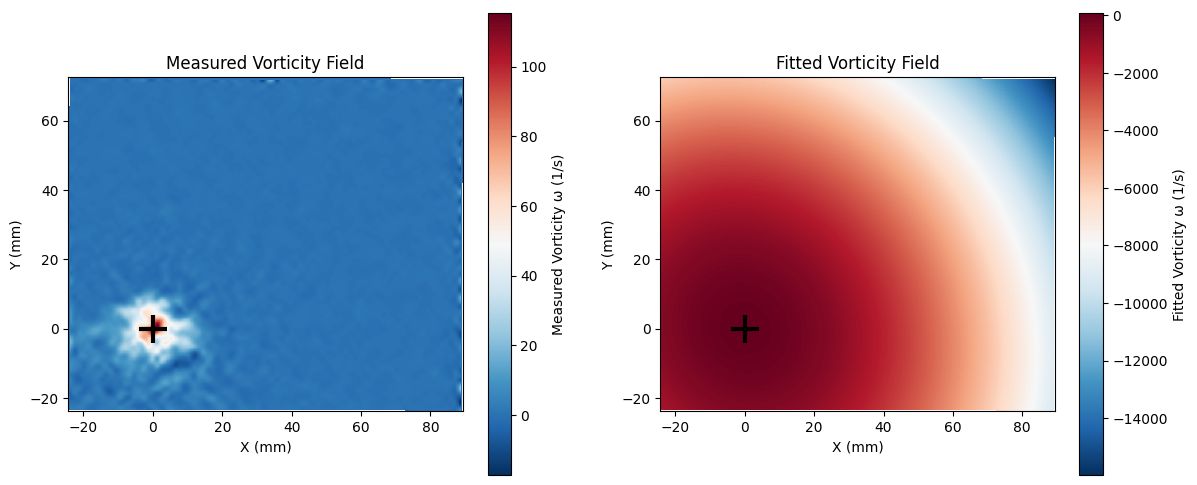

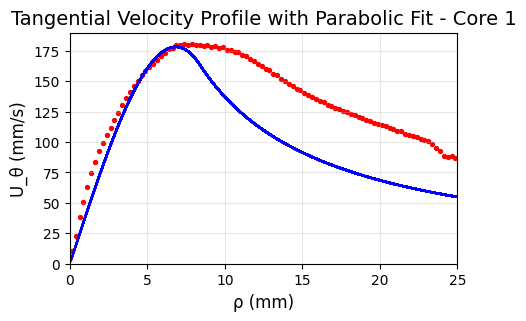


Predicted formation numbers from parabolic fit:
  ε = 0.465
  N₁ = 8.45
  N₂ = 14.63
  N₃ = 20.57


In [167]:
# Extract the fitted vorticity field over the full 2D grid
if quadratic_fit_success:
    omega_fit = quadratic_vorticity_model((dX, dY), *popt_vort)
    print(f"Fitted vorticity field shape: {omega_fit.shape}")
    print(f"  max = {omega_fit.max():.2f} 1/s,  min = {omega_fit.min():.2f} 1/s")
else:
    omega_fit = np.full_like(omega_half, np.nan)
    print("Quadratic fit was not successful; omega_fit filled with NaN.")

# plot the fitted vorticity field and actual vorticity field side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
im1 = ax1.pcolormesh(dX, dY, omega_half, cmap='RdBu_r', shading='auto')
plt.colorbar(im1, ax=ax1, label='Measured Vorticity ω (1/s)')
ax1.plot(0, 0, 'k+', markersize=20, markeredgewidth=3)
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_title('Measured Vorticity Field')
ax1.set_aspect('equal') 

ax2 = axes[1]
im2 = ax2.pcolormesh(dX, dY, omega_fit, cmap='RdBu_r', shading='auto')
plt.colorbar(im2, ax=ax2, label='Fitted Vorticity ω (1/s)')
ax2.plot(0, 0, 'k+', markersize=20, markeredgewidth=3)
ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_title('Fitted Vorticity Field')
ax2.set_aspect('equal')

# compute tangential velocity from the fitted vorticity using the parabolic model
if quadratic_fit_success and np.isfinite(a_eq):
    u_theta_parab, ai_parab = parabolic_vorticity_velocity(rho, omega_c, a_eq)
    print(f"Parabolic model: inner core radius a_i = {ai_parab:.2f} mm")
    
    # Plot the parabolic velocity profile
    plt.figure(figsize=(5, 3))
    valid = n_points > 2
    plt.scatter(r_centers[valid], U_theta_mean[valid], color='red', s=8, label='Mean tangential Velocity')
    plt.plot(rho, u_theta_parab, 'b-', label='Parabolic fit from quadratic vorticity')
    plt.xlabel('ρ (mm)', fontsize=12)
    plt.ylabel('U_θ (mm/s)', fontsize=12)
    plt.title(f'Tangential Velocity Profile with Parabolic Fit - Core {CORE_INDEX+1}', fontsize=14)
    plt.xlim(0, r_max)
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.3)
    plt.show()

# predict wave numbers using the parabolic fit parameters
if quadratic_fit_success and np.isfinite(a_eq):
    epsilon_parab = 0.47 * (ai_parab / a_eff) / (1.45 - 0.63 * (ai_parab / a_eff)) 
    ks1_parab, ks2_parab, ks3_parab = interpolate_kappa_values(epsilon_parab)["kappa1_s1"], interpolate_kappa_values(epsilon_parab)["kappa2_s1"], interpolate_kappa_values(epsilon_parab)["kappa3_s1"]
    
    N1_parab = ks1_parab * (a_eff / ai_parab) * np.exp(U_mean_nd + 1/4) / 8
    N2_parab = ks2_parab * (a_eff / ai_parab) * np.exp(U_mean_nd + 1/4) / 8
    N3_parab = ks3_parab * (a_eff / ai_parab) * np.exp(U_mean_nd + 1/4) / 8
    
    print(f"\nPredicted formation numbers from parabolic fit:")
    print(f'  ε = {epsilon_parab:.3f}')
    print(f"  N₁ = {N1_parab:.2f}")
    print(f"  N₂ = {N2_parab:.2f}")
    print(f"  N₃ = {N3_parab:.2f}")


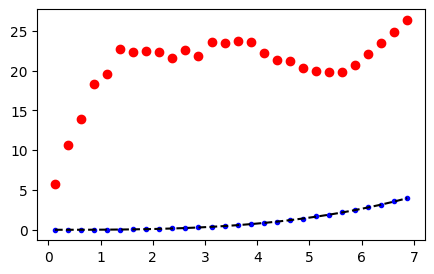

In [154]:
def u_rho_from_quadratic_fit(dX, dY, coeffs, recenter=True):
    """
    Radial velocity u_ρ induced by the quadratic vorticity fit
        ω(x', y') = a0 + a1·x' + a2·x'² + a3·x'·y' + a4·y' + a5·y'²
    
    A quadratic ω contains only m=0 and m=2 azimuthal components; the m=0 part
    contributes only to u_φ, so all of u_ρ comes from the m=2 (elliptic) part.
    Solving ∇²ψ = -ω in the m=2 sector with regularity at the origin and decay
    at infinity (no externally applied strain) gives ψ₂(ρ) = -(λ₁-λ₂)/48 · ρ⁴,
    hence
        u_ρ(ρ, φ) = (λ₁-λ₂)/24 · ρ³ · sin[2(φ-θ)]
    where λ₁, λ₂ are Hessian eigenvalues and θ is the angle of the eigenvector
    for λ₁ from the x-axis.
    
    Parameters
    ----------
    dX, dY : ndarray
        Displacements from the seed core centre (your `dX`, `dY` arrays).
    coeffs : array_like, length 6
        Quadratic fit coefficients [a0, a1, a2, a3, a4, a5] from `popt_vort`.
    recenter : bool, default True
        Recenter (ρ, φ) on the fit's extremum (x0, y0) before evaluating.
        Removes spurious m=1 leakage from a mismatch between the seed centre
        and the actual peak of the fitted vorticity.
    
    Returns
    -------
    u_rho_fit : ndarray
        u_ρ field on the same grid as dX, dY (mm/s if ω is in 1/s and dX, dY in mm).
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    H = np.array([[2*a2, a3], [a3, 2*a5]])
    eigvals, eigvecs = np.linalg.eig(H)
    lam1, lam2 = eigvals
    v1 = eigvecs[:, 0]
    theta = np.arctan2(v1[1], v1[0])     # angle of eigenvector for lam1
    
    if recenter:
        x0, y0 = np.linalg.solve(H, -np.array([a1, a4]))
        dX_eff, dY_eff = dX - x0, dY - y0
    else:
        dX_eff, dY_eff = dX, dY
    
    rho = np.sqrt(dX_eff**2 + dY_eff**2)
    phi = np.arctan2(dY_eff, dX_eff)
    
    return (lam1 - lam2) / 24.0 * rho**3 * np.sin(2.0 * (phi - theta))


def u_rho_amplitude_from_quadratic_fit(rho, coeffs):
    """
    Predicted amplitude of the m=2 u_ρ oscillation at radius ρ:
        U_ρ(ρ) = |λ₁ - λ₂| / 24 · ρ³
    
    Compare with binned reductions of measured u_ρ at the same ρ:
        RMS:           U_ρ(ρ) / √2
        mean(|u_ρ|):   (2/π) · U_ρ(ρ)
    """
    a0, a1, a2, a3, a4, a5 = coeffs
    H = np.array([[2*a2, a3], [a3, 2*a5]])
    eigvals, _ = np.linalg.eig(H)
    return np.abs(eigvals[0] - eigvals[1]) / 24.0 * np.asarray(rho)**3

# Single source of truth for shapes — recompute everything from dX, dY here
rho_2D = np.sqrt(dX**2 + dY**2)
assert u_rho.shape == dX.shape, (
    f"measured u_rho shape {u_rho.shape} != dX shape {dX.shape} — "
    f"re-run cells 9 and 14 to resync"
)

u_rho_fit_2D = u_rho_from_quadratic_fit(dX, dY, popt_vort)

rho_f       = rho_2D.flatten()
u_rho_fit_f = u_rho_fit_2D.flatten()
u_rho_meas_f = u_rho.flatten()      # measured u_ρ from Cell 14

u_rho_fit_rms  = np.zeros(n_bins)
u_rho_meas_rms = np.zeros(n_bins)
for i in range(n_bins):
    sel = (rho_f >= r_edges[i]) & (rho_f < r_edges[i+1])
    if sel.sum() > 2:
        u_rho_fit_rms[i]  = np.sqrt(np.mean(u_rho_fit_f[sel]**2))
        u_rho_meas_rms[i] = np.sqrt(np.mean(u_rho_meas_f[sel]**2))

# Analytic prediction (also RMS over φ)
U_rho_pred = u_rho_amplitude_from_quadratic_fit(r_centers, popt_vort) / np.sqrt(2)
# Plot the measured and fitted u_ρ RMS profiles
plt.figure(figsize=(5, 3))
plt.plot(r_centers[r_centers < radius_threshold], u_rho_meas_rms[r_centers < radius_threshold], 'ro', label='Measured u_ρ RMS')
plt.plot(r_centers[r_centers < radius_threshold], u_rho_fit_rms[r_centers < radius_threshold], 'b.', label='Fit u_ρ RMS')
plt.plot(r_centers[r_centers < radius_threshold], U_rho_pred[r_centers < radius_threshold], 'k--', label='Predicted U_ρ/√2')

---
## Step 9: Final Plot — Dazin et al. Figure 21 Style

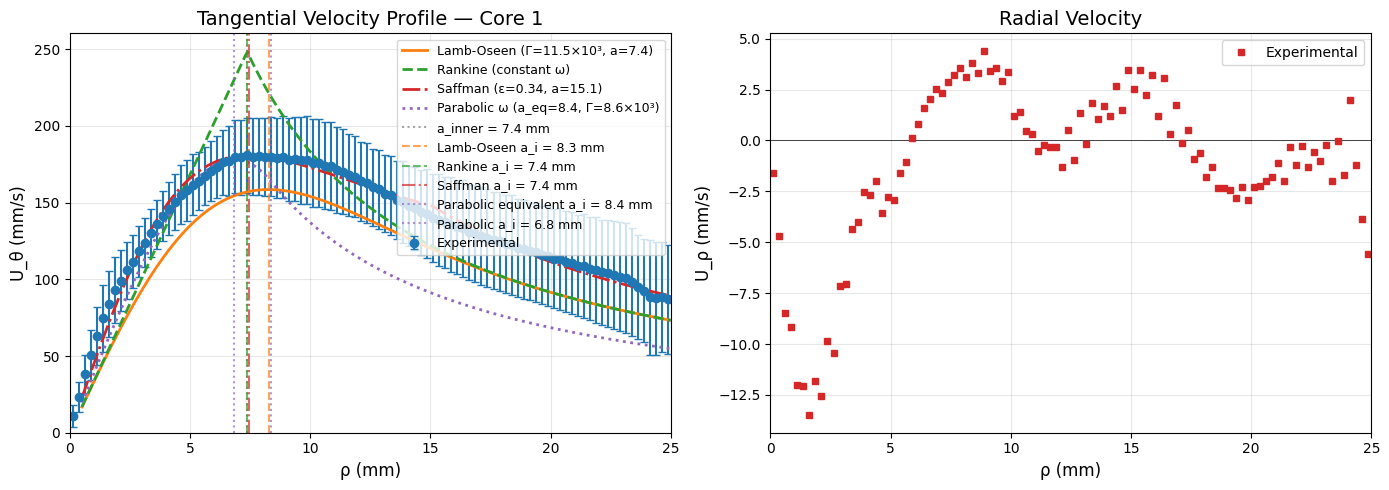


Figure saved to: velocity_profile_dazin_style.png


In [155]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Left panel: Tangential velocity profile =====
ax1 = axes[0]

# Experimental data
valid = n_points > 2
ax1.errorbar(r_centers[valid], U_theta_mean[valid], yerr=U_theta_std[valid],
             fmt='o', markersize=6, capsize=3, color='C0',
             label='Experimental')

# Theoretical curves (evaluated on a fine grid)
r_theory = np.linspace(0.5, r_max, 300)

# Lamb-Oseen (fitted)
u_lo, ai_lo = lamb_oseen(r_theory, gamma_fit, a_fit)
ax1.plot(r_theory, u_lo, '-', linewidth=2, color='C1',
         label=f'Lamb-Oseen (Γ={gamma_fit/1000:.1f}×10³, a={a_fit:.1f})')

# Rankine (same Γ, a as Lamb-Oseen for direct comparison)
u_rank, ai_rank = rankine_vortex(r_theory, gamma_fit, a_fit)
ax1.plot(r_theory, u_rank, '--', linewidth=2, color='C2',
         label='Rankine (constant ω)')

# Saffman hypergeometric (fitted)
if saffman_success:
    u_saf = saffman_profile(r_theory, gamma_saf, a_saf, epsilon_saf)
    ax1.plot(r_theory, u_saf, '-.', linewidth=2, color='C3',
             label=f'Saffman (ε={epsilon_saf:.2f}, a={a_saf:.1f})')

# Parabolic vorticity → velocity (from elliptical ω fit)
if quadratic_fit_success and np.isfinite(a_eq):
    u_parab, ai_parab = parabolic_vorticity_velocity(r_theory, np.abs(omega_c), a_eq)
    ax1.plot(r_theory, u_parab, ':', linewidth=2, color='C4',
             label=f'Parabolic ω (a_eq={a_eq:.1f}, Γ={gamma_parab/1000:.1f}×10³)')

# Mark inner core radius (location of peak u_θ)
ax1.axvline(a_inner, color='gray', linestyle=':', alpha=0.7,
            label=f'a_inner = {a_inner:.1f} mm')

ax1.axvline(ai_lo, color='C1', linestyle='--', alpha=0.7,
            label=f'Lamb-Oseen a_i = {ai_lo:.1f} mm')

ax1.axvline(ai_rank, color='C2', linestyle='--', alpha=0.7,
            label=f'Rankine a_i = {ai_rank:.1f} mm')

ax1.axvline(ai_saf, color='C3', linestyle='-.', alpha=0.7,
            label=f'Saffman a_i = {ai_saf:.1f} mm')

ax1.axvline(a_eq, color='C4', linestyle=':', alpha=0.7,
            label=f'Parabolic equivalent a_i = {a_eq:.1f} mm')

ax1.axvline(ai_parab, color='C4', linestyle=':', alpha=0.7,
            label=f'Parabolic a_i = {ai_parab:.1f} mm')

ax1.set_xlabel('ρ (mm)', fontsize=12)
ax1.set_ylabel('U_θ (mm/s)', fontsize=12)
ax1.set_title(f'Tangential Velocity Profile — Core {CORE_INDEX+1}', fontsize=14)
ax1.set_xlim(0, r_max)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# ===== Right panel: Radial velocity (diagnostic) =====
ax2 = axes[1]

ax2.errorbar(r_centers[valid], U_rho_mean[valid],
             fmt='s', markersize=5, color='C3',
             label='Experimental')
ax2.axhline(0, color='k', linestyle='-', linewidth=0.5)

ax2.set_xlabel('ρ (mm)', fontsize=12)
ax2.set_ylabel('U_ρ (mm/s)', fontsize=12)
ax2.set_title('Radial Velocity', fontsize=14)
ax2.set_xlim(0, r_max)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('velocity_profile_dazin_style.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: velocity_profile_dazin_style.png")


In [156]:
# ----------------------------------------------------------------------------
# Compute harmonic amplitudes for u_rho and u_theta at each radial bin
# ----------------------------------------------------------------------------
# Uses the same radial bins as the zero-order analysis (r_edges, r_centers)

rho_flat_full   = rho.flatten()
phi_flat_full   = phi.flatten()
u_rho_flat_full = u_rho.flatten()             # mean-flow-subtracted
u_theta_flat_full = u_theta_signed.flatten()

# # make the dimensional variables dimensionless using the inner core radius and velocity scale
# rho_flat_full /= length
# u_rho_flat_full /= velocity
# u_theta_flat_full /= velocity

# Harmonic amplitude arrays — subscripts follow Dazin's convention:
#   0 = zero-order (constant in phi)
#   1 = first-order  (cos/sin of phi)
#   2 = second-order (cos/sin of 2*phi)
A0_rho_bin  = np.zeros(n_bins);  A0_theta_bin  = np.zeros(n_bins)
A1c_rho_bin = np.zeros(n_bins);  A1c_theta_bin = np.zeros(n_bins)
A1s_rho_bin = np.zeros(n_bins);  A1s_theta_bin = np.zeros(n_bins)
A2c_rho_bin = np.zeros(n_bins);  A2c_theta_bin = np.zeros(n_bins)
A2s_rho_bin = np.zeros(n_bins);  A2s_theta_bin = np.zeros(n_bins)

resid_rho_bin   = np.full(n_bins, np.nan)  # std of residuals after removing 5 harmonics
resid_theta_bin = np.full(n_bins, np.nan)

min_points_for_fit = 6   # 5 coefficients + redundancy

for i in range(n_bins):
    mask = (rho_flat_full >= r_edges[i]) & (rho_flat_full < r_edges[i+1])
    if np.sum(mask) < min_points_for_fit:
        continue

    phi_bin  = phi_flat_full[mask]
    urho_bin = u_rho_flat_full[mask]
    uth_bin  = u_theta_flat_full[mask]

    # Design matrix: columns = {1, cos(phi), sin(phi), cos(2phi), sin(2phi)}
    A = np.column_stack([
        np.ones_like(phi_bin),
        np.cos(phi_bin),
        np.sin(phi_bin),
        np.cos(2 * phi_bin),
        np.sin(2 * phi_bin),
    ])

    coeffs_rho, *_ = np.linalg.lstsq(A, urho_bin, rcond=None)
    A0_rho_bin[i], A1c_rho_bin[i], A1s_rho_bin[i], A2c_rho_bin[i], A2s_rho_bin[i] = coeffs_rho
    resid_rho_bin[i] = np.std(urho_bin - A @ coeffs_rho)

    coeffs_th, *_ = np.linalg.lstsq(A, uth_bin, rcond=None)
    A0_theta_bin[i], A1c_theta_bin[i], A1s_theta_bin[i], A2c_theta_bin[i], A2s_theta_bin[i] = coeffs_th
    resid_theta_bin[i] = np.std(uth_bin - A @ coeffs_th)

n_valid = np.sum(~np.isnan(resid_rho_bin))
print(f"Harmonic decomposition complete.")
print(f"Bins with valid fits: {n_valid}/{n_bins}")

Harmonic decomposition complete.
Bins with valid fits: 100/100


In [157]:
# ----------------------------------------------------------------------------
# Non-dimensionalise the fit results
# ----------------------------------------------------------------------------
length   = a_inner                                 # length scale, mm
velocity = gamma_measured / (2 * np.pi * a_inner)  # velocity scale, mm/s

# Non-dimensional radial coordinate
r_centers_nd = r_centers / length
r_edges_nd   = r_edges   / length

# Non-dimensional amplitudes (divide each by the velocity scale)
A0_rho_nd   = A0_rho_bin   / velocity
A1c_rho_nd  = A1c_rho_bin  / velocity
A1s_rho_nd  = A1s_rho_bin  / velocity
A2c_rho_nd  = A2c_rho_bin  / velocity
A2s_rho_nd  = A2s_rho_bin  / velocity

A0_theta_nd  = A0_theta_bin  / velocity
A1c_theta_nd = A1c_theta_bin / velocity
A1s_theta_nd = A1s_theta_bin / velocity
A2c_theta_nd = A2c_theta_bin / velocity
A2s_theta_nd = A2s_theta_bin / velocity

resid_rho_nd   = resid_rho_bin   / velocity
resid_theta_nd = resid_theta_bin / velocity

print(f"Normalisation scales: length = {length:.2f} mm, velocity = {velocity:.2f} mm/s")

Normalisation scales: length = 7.38 mm, velocity = 248.34 mm/s


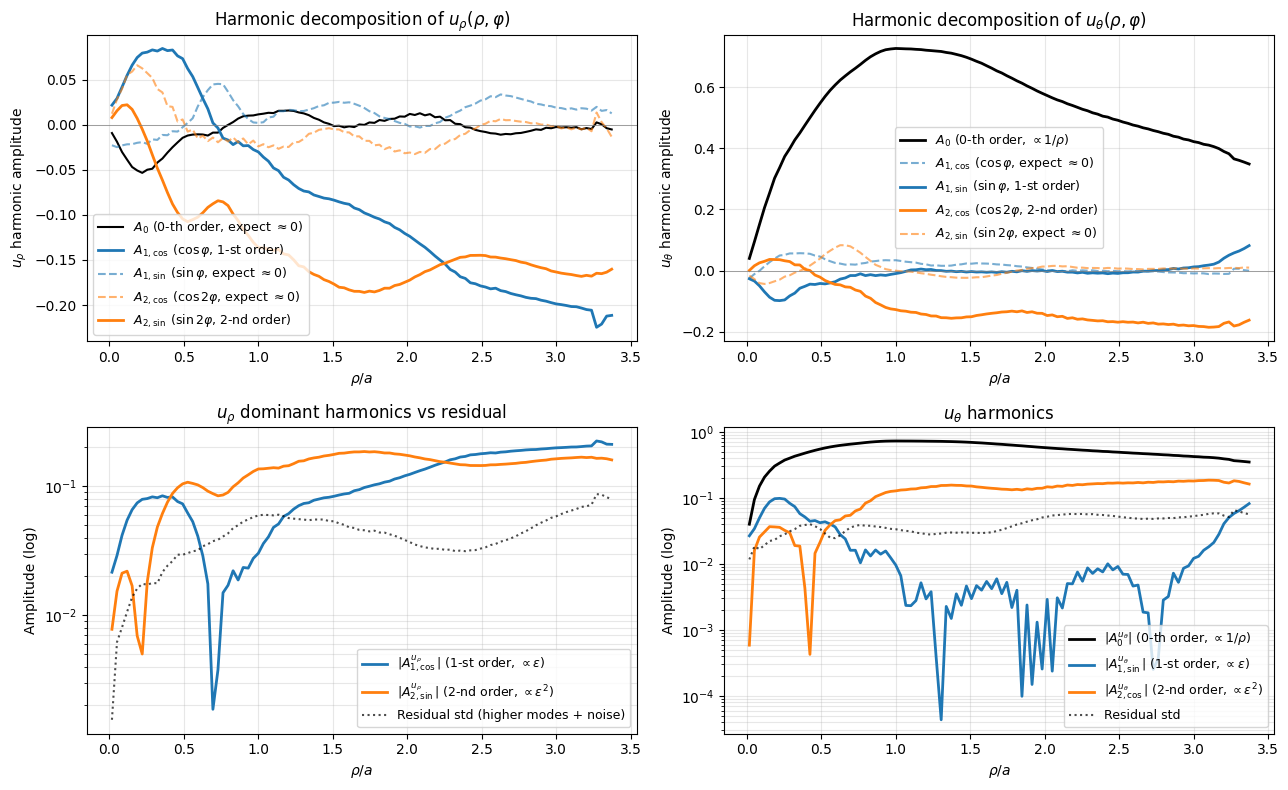

In [160]:
# ----------------------------------------------------------------------------
# Plot the harmonic amplitudes vs rho
# ----------------------------------------------------------------------------
# Dazin eq. (14) tells us which amplitudes SHOULD be large (dominant) and
# which SHOULD vanish for a well-behaved thin-core ring:
#
#   u_rho:    dominant -> A1c (cos(phi)),  A2s (sin(2*phi))
#             expect 0 -> A0, A1s, A2c
#   u_theta:  dominant -> A0 (1/rho), A1s (sin(phi)),  A2c (cos(2*phi))
#             expect 0 -> A1c, A2s

valid_mask = ~np.isnan(resid_rho_bin)
r_h = r_centers_nd[valid_mask]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Top-left: u_rho harmonics ---
ax = axes[0, 0]
ax.plot(r_h, A0_rho_nd[valid_mask],  'k-',   label=r'$A_0$ (0-th order, expect $\approx 0$)')
ax.plot(r_h, A1c_rho_nd[valid_mask], 'C0-',  label=r'$A_{1,\cos}$ ($\cos\varphi$, 1-st order)', linewidth=2)
ax.plot(r_h, A1s_rho_nd[valid_mask], 'C0--', label=r'$A_{1,\sin}$ ($\sin\varphi$, expect $\approx 0$)', alpha=0.6)
ax.plot(r_h, A2c_rho_nd[valid_mask], 'C1--', label=r'$A_{2,\cos}$ ($\cos 2\varphi$, expect $\approx 0$)', alpha=0.6)
ax.plot(r_h, A2s_rho_nd[valid_mask], 'C1-',  label=r'$A_{2,\sin}$ ($\sin 2\varphi$, 2-nd order)', linewidth=2)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(r'$\rho / a$')
ax.set_ylabel(r'$u_\rho$ harmonic amplitude')
ax.set_title(r'Harmonic decomposition of $u_\rho(\rho, \varphi)$')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)

# --- Top-right: u_theta harmonics ---
ax = axes[0, 1]
ax.plot(r_h, A0_theta_nd[valid_mask],  'k-',   label=r'$A_0$ (0-th order, $\propto 1/\rho$)', linewidth=2)
ax.plot(r_h, A1c_theta_nd[valid_mask], 'C0--', label=r'$A_{1,\cos}$ ($\cos\varphi$, expect $\approx 0$)', alpha=0.6)
ax.plot(r_h, A1s_theta_nd[valid_mask], 'C0-',  label=r'$A_{1,\sin}$ ($\sin\varphi$, 1-st order)', linewidth=2)
ax.plot(r_h, A2c_theta_nd[valid_mask], 'C1-',  label=r'$A_{2,\cos}$ ($\cos 2\varphi$, 2-nd order)', linewidth=2)
ax.plot(r_h, A2s_theta_nd[valid_mask], 'C1--', label=r'$A_{2,\sin}$ ($\sin 2\varphi$, expect $\approx 0$)', alpha=0.6)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(r'$\rho / a$')
ax.set_ylabel(r'$u_\theta$ harmonic amplitude')
ax.set_title(r'Harmonic decomposition of $u_\theta(\rho, \varphi)$')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)

# --- Bottom-left: u_rho dominant harmonics vs residual (log scale) ---
ax = axes[1, 0]
ax.semilogy(r_h, np.abs(A1c_rho_nd[valid_mask]), 'C0-', linewidth=2,
            label=r'$|A_{1,\cos}^{u_\rho}|$ (1-st order, $\propto \varepsilon$)')
ax.semilogy(r_h, np.abs(A2s_rho_nd[valid_mask]), 'C1-', linewidth=2,
            label=r'$|A_{2,\sin}^{u_\rho}|$ (2-nd order, $\propto \varepsilon^2$)')
ax.semilogy(r_h, resid_rho_nd[valid_mask], 'k:', alpha=0.7,
            label='Residual std (higher modes + noise)')
ax.set_xlabel(r'$\rho / a$')
ax.set_ylabel('Amplitude (log)')
ax.set_title(r'$u_\rho$ dominant harmonics vs residual')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

# --- Bottom-right: u_theta equivalent ---
ax = axes[1, 1]
ax.semilogy(r_h, np.abs(A0_theta_nd[valid_mask]),  'k-',  linewidth=2,
            label=r'$|A_0^{u_\theta}|$ (0-th order, $\propto 1/\rho$)')
ax.semilogy(r_h, np.abs(A1s_theta_nd[valid_mask]), 'C0-', linewidth=2,
            label=r'$|A_{1,\sin}^{u_\theta}|$ (1-st order, $\propto \varepsilon$)')
ax.semilogy(r_h, np.abs(A2c_theta_nd[valid_mask]), 'C1-', linewidth=2,
            label=r'$|A_{2,\cos}^{u_\theta}|$ (2-nd order, $\propto \varepsilon^2$)')
ax.semilogy(r_h, resid_theta_nd[valid_mask], 'k:', alpha=0.7, label='Residual std')
ax.set_xlabel(r'$\rho / a$')
ax.set_ylabel('Amplitude (log)')
ax.set_title(r'$u_\theta$ harmonics')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('harmonic_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [161]:
# ----------------------------------------------------------------------------
# Measurement-based slenderness estimate from harmonic ratios
# ----------------------------------------------------------------------------
# In Dazin (14), u_theta (dimensionless) = 1/rho + epsilon * (...) * sin(phi) + epsilon^2 * (...) * cos(2*phi)
# Evaluating the ratio of 1st-order to 0-th-order at a characteristic radius
# gives a direct order-of-magnitude estimate of epsilon = a/R, independent
# of any ring-radius measurement.
#
# Note: this gives epsilon up to an O(1) coefficient (the bracketed function
# at that specific rho), so treat it as an order-of-magnitude consistency
# check rather than a precise value.

i_at_a = np.argmin(np.abs(r_centers - a_inner))

A0_at_a  = A0_theta_bin[i_at_a]
A1s_at_a = A1s_theta_bin[i_at_a]
A2c_at_a = A2c_theta_bin[i_at_a]

epsilon_from_harmonics = np.abs(A1s_at_a / A0_at_a) if A0_at_a != 0 else np.nan
eps2_ratio             = np.abs(A2c_at_a / A0_at_a) if A0_at_a != 0 else np.nan

print(f"Slenderness estimate from harmonic amplitudes (evaluated at rho = a_inner = {a_inner:.2f} mm):")
print(f"  A_0^(u_theta)       = {A0_at_a:+8.2f} mm/s   (0-th order, 1/rho term)")
print(f"  A_1,sin^(u_theta)   = {A1s_at_a:+8.2f} mm/s   (1-st order, ~ epsilon)")
print(f"  A_2,cos^(u_theta)   = {A2c_at_a:+8.2f} mm/s   (2-nd order, ~ epsilon^2)")
print()
print(f"  |A_1/A_0|  = {epsilon_from_harmonics:.3f}  -> implied epsilon")
print(f"  |A_2/A_0|  = {eps2_ratio:.3f}  -> should be ~ epsilon^2 = {epsilon_from_harmonics**2:.3f}")
print()
print(f"  Consistency: |A_2/A_0| / |A_1/A_0|^2 = {eps2_ratio / epsilon_from_harmonics**2:.2f}")
print(f"  (should be O(1) if the asymptotic expansion is well-behaved at this rho)")

Slenderness estimate from harmonic amplitudes (evaluated at rho = a_inner = 7.38 mm):
  A_0^(u_theta)       =  +180.33 mm/s   (0-th order, 1/rho term)
  A_1,sin^(u_theta)   =    -2.38 mm/s   (1-st order, ~ epsilon)
  A_2,cos^(u_theta)   =   -31.63 mm/s   (2-nd order, ~ epsilon^2)

  |A_1/A_0|  = 0.013  -> implied epsilon
  |A_2/A_0|  = 0.175  -> should be ~ epsilon^2 = 0.000

  Consistency: |A_2/A_0| / |A_1/A_0|^2 = 1004.26
  (should be O(1) if the asymptotic expansion is well-behaved at this rho)


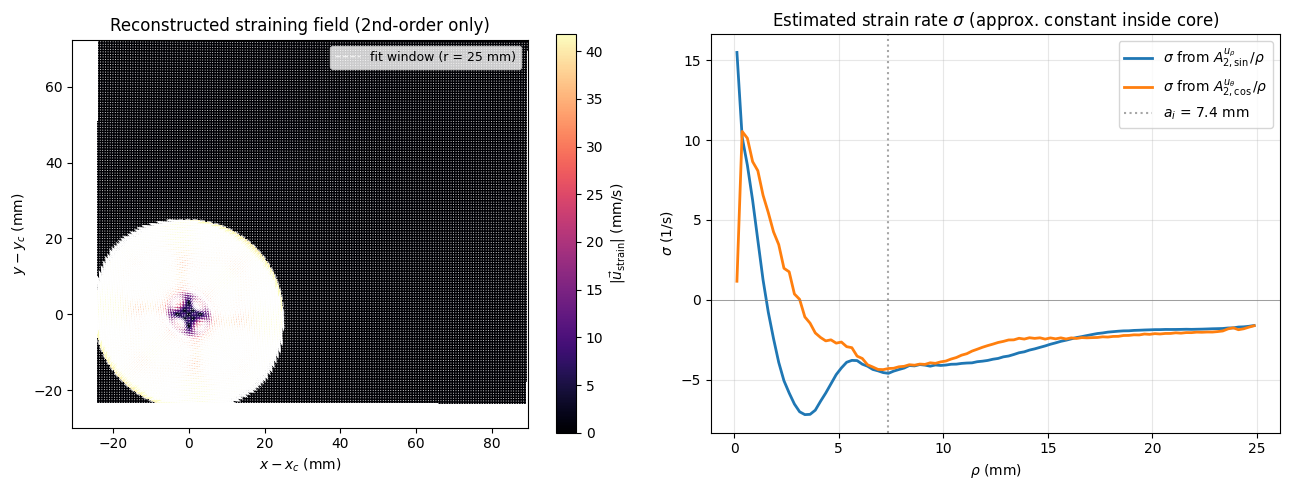

Strain rate sigma (at rho = a_inner = 7.38 mm):
  From A_2,sin(u_rho)   : sigma = -4.5908 1/s
  From A_2,cos(u_theta) : sigma = -4.2894 1/s
  Mean |sigma|          : sigma = 4.4401 1/s

This sigma can be plugged directly into Saffman's growth-rate formula:
    alpha = sqrt( sigma^2 * P^2 - (k - k_c)^2 * Q^2 )
bypassing the need to back-calculate sigma from thin-ring theory.


In [162]:
# ----------------------------------------------------------------------------
# Reconstruct the straining field (2nd-order only) — saddle-point signature
# of the Widnall-Tsai instability mechanism
# ----------------------------------------------------------------------------
from scipy.interpolate import interp1d

valid_for_interp = ~np.isnan(resid_rho_bin)
r_for_interp = r_centers[valid_for_interp]

A2s_rho_func   = interp1d(r_for_interp, A2s_rho_bin[valid_for_interp],
                          bounds_error=False, fill_value=0.0)
A2c_theta_func = interp1d(r_for_interp, A2c_theta_bin[valid_for_interp],
                          bounds_error=False, fill_value=0.0)

# Evaluate on the (dX, dY) grid
rho_grid = np.sqrt(dX**2 + dY**2)
phi_grid = np.arctan2(dY, dX)

u_rho_strain   = A2s_rho_func(rho_grid)   * np.sin(2 * phi_grid)
u_theta_strain = A2c_theta_func(rho_grid) * np.cos(2 * phi_grid)

# Convert back to Cartesian for display
u_cart_strain = u_rho_strain * np.cos(phi_grid) - u_theta_strain * np.sin(phi_grid)
v_cart_strain = u_rho_strain * np.sin(phi_grid) + u_theta_strain * np.cos(phi_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: straining field map ---
ax = axes[0]
speed_strain = np.sqrt(u_cart_strain**2 + v_cart_strain**2)
vmax = np.nanpercentile(speed_strain, 95)
im = ax.pcolormesh(dX, dY, speed_strain, cmap='magma',
                   vmin=0, vmax=vmax, shading='auto')
plt.colorbar(im, ax=ax, label=r'$|\vec u_\mathrm{strain}|$ (mm/s)')

skip = 4
ax.quiver(dX[::skip, ::skip], dY[::skip, ::skip],
          u_cart_strain[::skip, ::skip], v_cart_strain[::skip, ::skip],
          color='white', scale=None)

# Fit-window outline
theta_circ = np.linspace(0, 2*np.pi, 200)
ax.plot(r_max * np.cos(theta_circ), r_max * np.sin(theta_circ), 'w--', lw=1, alpha=0.7,
        label=f'fit window (r = {r_max} mm)')

ax.set_xlabel(r'$x - x_c$ (mm)')
ax.set_ylabel(r'$y - y_c$ (mm)')
ax.set_title('Reconstructed straining field (2nd-order only)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)

# --- Right: strain rate sigma vs rho ---
# Inside the core, to leading order the straining flow has
#   u_rho ~ sigma * rho * sin(2*phi)
# so sigma ~ A_{2,sin}(u_rho) / rho.
ax = axes[1]
r_h = r_centers[valid_mask]
sigma_from_rho   = A2s_rho_bin[valid_mask]   / np.maximum(r_h, 1e-6)
sigma_from_theta = A2c_theta_bin[valid_mask] / np.maximum(r_h, 1e-6)
ax.plot(r_h, sigma_from_rho,   'C0-', linewidth=2,
        label=r'$\sigma$ from $A_{2,\sin}^{u_\rho}/\rho$')
ax.plot(r_h, sigma_from_theta, 'C1-', linewidth=2,
        label=r'$\sigma$ from $A_{2,\cos}^{u_\theta}/\rho$')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(a_inner, color='gray', linestyle=':', alpha=0.7,
           label=f'$a_i$ = {a_inner:.1f} mm')
ax.set_xlabel(r'$\rho$ (mm)')
ax.set_ylabel(r'$\sigma$ (1/s)')
ax.set_title(r'Estimated strain rate $\sigma$ (approx. constant inside core)')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('straining_field.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Summary values ----
sigma_at_ai_rho   = A2s_rho_bin[i_at_a]   / a_inner
sigma_at_ai_theta = A2c_theta_bin[i_at_a] / a_inner
sigma_mean_abs    = 0.5 * (np.abs(sigma_at_ai_rho) + np.abs(sigma_at_ai_theta))

print(f"Strain rate sigma (at rho = a_inner = {a_inner:.2f} mm):")
print(f"  From A_2,sin(u_rho)   : sigma = {sigma_at_ai_rho:+.4f} 1/s")
print(f"  From A_2,cos(u_theta) : sigma = {sigma_at_ai_theta:+.4f} 1/s")
print(f"  Mean |sigma|          : sigma = {sigma_mean_abs:.4f} 1/s")
print()
print(f"This sigma can be plugged directly into Saffman's growth-rate formula:")
print(f"    alpha = sqrt( sigma^2 * P^2 - (k - k_c)^2 * Q^2 )")
print(f"bypassing the need to back-calculate sigma from thin-ring theory.")

half band with is given by
$$
\frac{\sigma P Q}{R} = \frac{3P}{8 \beta} \frac{a}{R} \left[ \ln{\frac{8R}{a_{eff}}} - \frac{17}{12} \right]
$$

### Method 1 - use the strain rate sigma find from $u_\rho$ and $u_\theta$ higher order terms

In [166]:

# ============================================================================
# Saffman 1978 Table 2 — interpolator for P_n and β_n = 2π·a·Q_n / Γ
# ============================================================================
# Table 2 values for the rotation profile (2.16), in increasing-ε order.
# (The published ε=0.2, P_2 entry "0.566" is an OCR/typo for 1.566 —
#  monotone trend across the column confirms this.)

def interpolate_PQ_values(epsilon: float):
    """Saffman (1978) Table 2 — P_n and β_n = 2π·a·Q_n / Γ, n = 1, 2, 3.

    Linear interpolation on tabulated values.  Validity: 0.05 ≤ ε ≤ ∞;
    above ε = 5 we clamp to the ε = 5 row (which already matches ε = ∞ to 3 s.f.).
    """
    if epsilon < 0.05:
        raise ValueError("Saffman Table 2 only tabulated for ε ≥ 0.05")

    eps_data   = np.array([0.05,  0.1,   0.2,   0.3,   0.4,   0.5,   0.6,   0.7,   0.8,   0.9,   1.0,   5.0])
    P1_data    = np.array([1.718, 1.670, 1.563, 1.465, 1.392, 1.341, 1.303, 1.274, 1.252, 1.234, 1.220, 1.145])
    beta1_data = np.array([0.007, 0.034, 0.110, 0.180, 0.220, 0.250, 0.260, 0.260, 0.270, 0.270, 0.270, 0.270])
    P2_data    = np.array([1.684, 1.646, 1.566, 1.475, 1.397, 1.340, 1.300, 1.271, 1.248, 1.231, 1.217, 1.143])
    beta2_data = np.array([0.002, 0.009, 0.045, 0.094, 0.130, 0.150, 0.160, 0.170, 0.170, 0.170, 0.170, 0.160])
    P3_data    = np.array([1.653, 1.623, 1.558, 1.476, 1.396, 1.338, 1.297, 1.267, 1.245, 1.227, 1.213, 1.140])
    beta3_data = np.array([0.001, 0.006, 0.028, 0.061, 0.092, 0.110, 0.120, 0.120, 0.120, 0.120, 0.120, 0.120])

    eps_eval = min(epsilon, 5.0)
    return {
        "epsilon": epsilon,
        "P1":    float(np.interp(eps_eval, eps_data, P1_data)),
        "beta1": float(np.interp(eps_eval, eps_data, beta1_data)),
        "P2":    float(np.interp(eps_eval, eps_data, P2_data)),
        "beta2": float(np.interp(eps_eval, eps_data, beta2_data)),
        "P3":    float(np.interp(eps_eval, eps_data, P3_data)),
        "beta3": float(np.interp(eps_eval, eps_data, beta3_data)),
    }


# ============================================================================
# General half-bandwidth function (Saffman eq. 5.2)
# ============================================================================
def half_band_N(sigma, P, beta, a, R, Gamma):
    """Half-bandwidth in N = k·R units = σ·P·R/Q."""
    return sigma * P * R * 2.0 * np.pi * a / (beta * Gamma)


def band_centre_N(ks_n_value, R, a_i):
    """Band centre N_c = k_c·R, with k_c = (κ·s_1) / a_i from Saffman Table 1."""
    return ks_n_value * R / a_i


# ============================================================================
# Models — each tuple carries its own ε for independent PQ / κ look-ups
# ============================================================================
# (name,  a_outer,    a_inner,    epsilon_to_use)
models = [
    ("Rankine",   ai_rankine,  ai_rankine,  epsilon_tankine),
    ("Saffman",   a_saf,       ai_saf,      epsilon_saf),
    ("Quadratic", a_eq,        ai_parab,    epsilon_parab),
    ("Actual",    a_eq,        a_inner,     epsilon_actual),
]

# Print the per-model Table-1 and Table-2 values for reference
print("Per-model Saffman table values:")
print(f"  {'Model':<10} {'ε':>6}  {'ks₁':>6} {'ks₂':>6} {'ks₃':>6}  "
      f"{'P₁':>6} {'P₂':>6} {'P₃':>6}  {'β₁':>6} {'β₂':>6} {'β₃':>6}")
for name, a, a_i, eps in models:
    kap = interpolate_kappa_values(eps)
    pq  = interpolate_PQ_values(eps)
    print(f"  {name:<10} {eps:6.3f}  "
          f"{kap['kappa1_s1']:6.3f} {kap['kappa2_s1']:6.3f} {kap['kappa3_s1']:6.3f}  "
          f"{pq['P1']:6.3f} {pq['P2']:6.3f} {pq['P3']:6.3f}  "
          f"{pq['beta1']:6.3f} {pq['beta2']:6.3f} {pq['beta3']:6.3f}")

# ============================================================================
# METHOD 1 — measured σ from the (u_ρ, u_θ) m=2 harmonics (Cell 47)
# ============================================================================
sigma_meas = sigma_mean_abs

print("\n" + "=" * 84)
print(f"METHOD 1  —  measured σ = {sigma_meas:.4f} 1/s "
      f"(from u_ρ, u_θ second-order harmonics)")
print("=" * 84)
header_top = f"{'Model':<10} {'ε':>5} {'a':>6} {'a_i':>6}  " + \
             "  ".join([f"{'Mode '+str(n):>22}" for n in (1, 2, 3)])
header_bot = f"{'':10} {'':>5} {'(mm)':>6} {'(mm)':>6}  " + \
             "  ".join([f"{'N_c   [N_lo, N_hi]':>22}" for _ in (1, 2, 3)])
print(header_top)
print(header_bot)
print("-" * 84)

for name, a, a_i, eps in models:
    kap = interpolate_kappa_values(eps)
    pq  = interpolate_PQ_values(eps)
    ks_model   = [kap["kappa1_s1"], kap["kappa2_s1"], kap["kappa3_s1"]]
    P_model    = [pq["P1"],    pq["P2"],    pq["P3"]]
    beta_model = [pq["beta1"], pq["beta2"], pq["beta3"]]
    cells = []
    for n in range(3):
        Nc = band_centre_N(ks_model[n], ring_radius, a_i)
        hb = half_band_N(sigma_meas, P_model[n], beta_model[n], a, ring_radius, gamma_measured)
        cells.append(f"{Nc:5.2f} [{Nc-hb:5.2f},{Nc+hb:5.2f}]")
    print(f"{name:<10} {eps:5.3f} {a:6.2f} {a_i:6.2f}  " + "  ".join(cells))


Per-model Saffman table values:
  Model           ε     ks₁    ks₂    ks₃      P₁     P₂     P₃      β₁     β₂     β₃
  Rankine     0.650   2.899  5.028  7.118   1.289  1.286  1.282   0.260  0.165  0.120
  Saffman     0.340   2.261  3.903  5.469   1.436  1.444  1.444   0.196  0.108  0.073
  Quadratic   0.465   2.493  4.316  6.070   1.359  1.360  1.358   0.239  0.143  0.104
  Actual      0.527   2.623  4.549  6.410   1.331  1.329  1.327   0.253  0.153  0.113

METHOD 1  —  measured σ = 4.4401 1/s (from u_ρ, u_θ second-order harmonics)
Model          ε      a    a_i                  Mode 1                  Mode 2                  Mode 3
                   (mm)   (mm)      N_c   [N_lo, N_hi]      N_c   [N_lo, N_hi]      N_c   [N_lo, N_hi]
------------------------------------------------------------------------------------
Rankine    0.650   8.29   8.29   8.10 [ 5.79,10.41]  14.05 [10.42,17.68]  19.89 [14.91,24.86]
Saffman    0.340  15.11   7.44   7.04 [ 0.82,13.26]  12.15 [ 0.84,23.47]  17

In [168]:

# ============================================================================
# METHOD 2 — analytical σ from Saffman eq. (4.2)
# ============================================================================
#   σ = (3·Γ) / (16·π·R²) · [ ln(8R / a_e) − 17/12 ]

L_factor  = np.log(8 * ring_radius / a_eff) - 17/12
sigma_th  = 3 * gamma_measured / (16 * np.pi * ring_radius**2) * L_factor

print(f"Analytical strain rate (Saffman eq. 4.2):")
print(f"  ln(8R/a_e) − 17/12 = {L_factor:.3f}")
print(f"  σ = (3Γ)/(16πR²) · [..]  = {sigma_th:.4f} 1/s")
print(f"  (compare measured σ from harmonics = {sigma_meas:.4f} 1/s,  "
      f"ratio σ_th/σ_meas = {sigma_th/sigma_meas:.2f})")

print("\n" + "=" * 84)
print(f"METHOD 2  —  analytical σ = {sigma_th:.4f} 1/s  (Saffman eq. 4.2)")
print("=" * 84)
print(header_top)
print(header_bot)
print("-" * 84)

for name, a, a_i, eps in models:
    kap = interpolate_kappa_values(eps)
    pq  = interpolate_PQ_values(eps)
    ks_model   = [kap["kappa1_s1"], kap["kappa2_s1"], kap["kappa3_s1"]]
    P_model    = [pq["P1"],    pq["P2"],    pq["P3"]]
    beta_model = [pq["beta1"], pq["beta2"], pq["beta3"]]
    cells = []
    for n in range(3):
        Nc = band_centre_N(ks_model[n], ring_radius, a_i)
        hb = half_band_N(sigma_th, P_model[n], beta_model[n], a, ring_radius, gamma_measured)
        cells.append(f"{Nc:5.2f} [{Nc-hb:5.2f},{Nc+hb:5.2f}]")
    print(f"{name:<10} {eps:5.3f} {a:6.2f} {a_i:6.2f}  " + "  ".join(cells))


# ============================================================================
# Bandwidth-only summary (sanity check vs. the user's markdown formula)
# ============================================================================
# Method 2 closed form:  half-band = (3·P_n)/(8·β_n) · (a/R) · L_factor
# This must agree with the table above.


Analytical strain rate (Saffman eq. 4.2):
  ln(8R/a_e) − 17/12 = 1.759
  σ = (3Γ)/(16πR²) · [..]  = 2.2515 1/s
  (compare measured σ from harmonics = 4.4401 1/s,  ratio σ_th/σ_meas = 0.51)

METHOD 2  —  analytical σ = 2.2515 1/s  (Saffman eq. 4.2)
Model          ε      a    a_i                  Mode 1                  Mode 2                  Mode 3
                   (mm)   (mm)      N_c   [N_lo, N_hi]      N_c   [N_lo, N_hi]      N_c   [N_lo, N_hi]
------------------------------------------------------------------------------------
Rankine    0.650   8.29   8.29   8.10 [ 6.93, 9.27]  14.05 [12.21,15.89]  19.89 [17.37,22.41]
Saffman    0.340  15.11   7.44   7.04 [ 3.89,10.19]  12.15 [ 6.41,17.89]  17.02 [ 8.55,25.50]
Quadratic  0.465   8.37   6.81   8.48 [ 7.13, 9.83]  14.68 [12.42,16.95]  20.65 [17.52,23.77]
Actual     0.527   8.37   7.38   8.24 [ 6.98, 9.49]  14.29 [12.21,16.36]  20.14 [17.33,22.94]
